# Notebook 07 - Round 2: Combined Pipeline
**ECE 5424 Advanced ML Capstone** | Virginia Tech Spring 2026

---

This notebook consolidates the full pipeline learned across Notebooks 1–6 into a single document (EDA, data engineering, training, evaluation).

## What changed from Notebook 06(round1)
| Issue identified | Fix applied |
|-----------------|-------------|
| Person/pole absent from `zurich_city_04_a` | Add `zurich_city_00_a` (city street sequence) |
| Weighted CE destabilises Model C SNN | Use `label_smoothing=0.1` for Model C only |
| EDA done after training | **EDA is Step 1 before any training code** |
| Depth not normalised in baseline | `normalize_depth=True` carried forward from R1 |

## Round 1 results (reference)
| Model | Baseline | R1 | Status |
|-------|----------|-----|--------|
| A: Depth-only CNN | 0.0799 | 0.0871 | +0.007 |
| B: Early Fusion CNN | 0.1457 | 0.1470 | +0.003 |
| C: SNN + Smart Gate | 0.1284 | 0.1098 | −0.019 (weighted CE incompatible with SNN) |

## Steps
1. **EDA** - class frequency audit on both sequences before touching training
2. **LiDAR pipeline** - extract sweeps, match timestamps, project depth for `zurich_city_00_a`
3. **Combined dataset** - ConcatDataset, recomputed weights from EDA counts
4. **Training** - weighted CE for A/B, label smoothing for C, gradient clipping for all
5. **Evaluation** - per-class IoU, confusion matrix, three-round summary table

## 0. Imports and Paths

In [1]:
import sys
from pathlib import Path
REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT))

import struct
import json
import yaml
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import hdf5plugin
import h5py
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, ConcatDataset, random_split
from rosbags.rosbag1 import Reader
from rosbags.typesys import Stores, get_typestore
from tqdm import tqdm
from config import DATA_ROOT

from src.datasets.dsec_dataset import DSECFusionDataset
from src.models.smart_gate_model import DepthOnlyCNN, EarlyFusionCNN, SmartGateModel

DATA_ROOT = Path(DATA_ROOT)
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DSEC_CLASS_NAMES = [
    'background', 'building', 'fence', 'person', 'pole',
    'road', 'sidewalk', 'vegetation', 'car', 'wall', 'traffic sign'
]
NUM_CLASSES = 11

print(f'Device  : {device}')
print(f'PyTorch : {torch.__version__}')

Device  : cuda
PyTorch : 2.5.1+cu121


---
## 1.EDA: Class Frequency Audit


Round 1 post trainning EDA revealed that `person` and `pole` have zero IoU across all models because `zurich_city_04_a` is a highway sequence, those classes simply don't appear. We were upweighting phantom classes and destabilising training.

This cell counts every pixel in every label file for both sequences. The output informs the weighting strategy in Step 3.

In [2]:
def class_frequency_audit(semantic_dir, sequence_name):
    label_files = sorted(Path(semantic_dir).glob('*.png'))
    if not label_files:
        print(f'  WARNING: No PNG files found in {semantic_dir}')
        return np.zeros(NUM_CLASSES, dtype=np.int64)

    counts = np.zeros(NUM_CLASSES, dtype=np.int64)
    for lf in label_files:
        lbl = cv2.imread(str(lf), cv2.IMREAD_GRAYSCALE)
        if lbl is None:
            continue
        for c in range(NUM_CLASSES):
            counts[c] += int((lbl == c).sum())

    total = counts.sum()
    print(f'\n{sequence_name} — {len(label_files)} frames:')
    print(f'{"Class":<15} {"Pixels":>12} {"Freq%":>8} {"Present":>9}')
    print('-' * 50)
    for name, c in zip(DSEC_CLASS_NAMES, counts):
        present = '  YES' if c > 0 else '  ABSENT'
        print(f'{name:<15} {c:>12,} {c/total*100:>7.3f}%{present}')
    return counts


SEQ_04A = 'zurich_city_04_a'
SEQ_00A = 'zurich_city_00_a'

sem_04a = DATA_ROOT / SEQ_04A / f'{SEQ_04A}_semantic' / SEQ_04A / '11classes'
sem_00a = DATA_ROOT / SEQ_00A / f'{SEQ_00A}_semantic' / SEQ_00A / '11classes'

counts_04a = class_frequency_audit(sem_04a, SEQ_04A)
counts_00a = class_frequency_audit(sem_00a, SEQ_00A)

counts_combined = counts_04a + counts_00a
total_combined  = counts_combined.sum()
print(f'\nCombined ({SEQ_04A} + {SEQ_00A}):')
print(f'{"Class":<15} {"Freq%":>8} {"Present":>9}')
print('-' * 36)
for name, c in zip(DSEC_CLASS_NAMES, counts_combined):
    present = '  YES' if c > 0 else '  ABSENT'
    print(f'{name:<15} {c/total_combined*100:>7.3f}%{present}')


zurich_city_04_a — 701 frames:
Class                 Pixels    Freq%   Present
--------------------------------------------------
background        17,917,025   9.076%  YES
building          44,458,463  22.522%  YES
fence              2,022,302   1.024%  YES
person               224,099   0.114%  YES
pole               2,395,622   1.214%  YES
road              72,427,756  36.691%  YES
sidewalk           6,399,219   3.242%  YES
vegetation        39,699,943  20.111%  YES
car                9,293,103   4.708%  YES
wall               1,252,814   0.635%  YES
traffic sign       1,311,254   0.664%  YES

zurich_city_00_a — 939 frames:
Class                 Pixels    Freq%   Present
--------------------------------------------------
background        35,692,023  13.498%  YES
building          57,403,727  21.709%  YES
fence              2,564,820   0.970%  YES
person               332,686   0.126%  YES
pole               3,356,904   1.270%  YES
road             100,224,102  37.903%  YES
sidewal

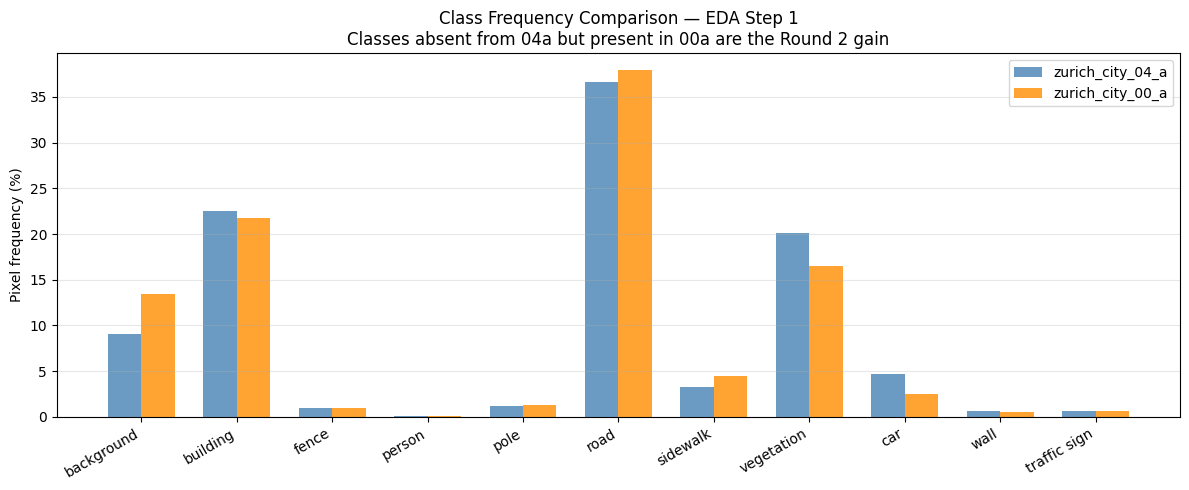

Saved to docs/figures/eda_class_frequency_r2.png


In [3]:
# Bar chart: pixel frequency per class per sequence
fig, ax = plt.subplots(figsize=(12, 5))
x   = np.arange(NUM_CLASSES)
w   = 0.35
t04 = counts_04a / counts_04a.sum() * 100
t00 = counts_00a / counts_00a.sum() * 100 if counts_00a.sum() > 0 else np.zeros(NUM_CLASSES)
ax.bar(x - w/2, t04, w, label=SEQ_04A, color='steelblue',  alpha=0.8)
ax.bar(x + w/2, t00, w, label=SEQ_00A, color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(DSEC_CLASS_NAMES, rotation=30, ha='right')
ax.set_ylabel('Pixel frequency (%)')
ax.set_title('Class Frequency Comparison — EDA Step 1\n'
             'Classes absent from 04a but present in 00a are the Round 2 gain')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
figures_dir = REPO_ROOT / 'docs' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figures_dir / 'eda_class_frequency_r2.png', dpi=150)
plt.show()
print('Saved to docs/figures/eda_class_frequency_r2.png')

---
## 2.LiDAR Pipeline for `zurich_city_00_a`

Replicates the Sessions 1–2 pipeline (Notebooks 03 and 04) on the new sequence.
Functions are copied verbatim from those notebooks.

Sub-steps:
- **2A**: Collect LiDAR timestamps from the bag
- **2B**: Load event timestamps to find the overlap window
- **2C**: Extract LiDAR point clouds (sweeps within overlap)
- **2D**: Temporal matching pair each semantic frame to nearest LiDAR sweep
- **2E**: Read calibration and project depth maps

In [4]:
#  Shared utility functions (from Notebooks 03 and 04)

def parse_pointcloud2(msg):
    """
    Extract x, y, z, intensity from a ROS1 PointCloud2 message.
    Returns (N, 4) float32 array of valid (non-NaN, non-zero) points.
    Copied verbatim from Notebook 03, Cell 14.
    """
    field_map        = {f.name: f.offset for f in msg.fields}
    point_step       = msg.point_step
    data             = bytes(msg.data)
    n_points         = len(data) // point_step
    intensity_offset = field_map.get('intensity', field_map.get('i', None))

    pts = np.zeros((n_points, 4), dtype=np.float32)
    for i in range(n_points):
        base      = i * point_step
        pts[i, 0] = struct.unpack_from('f', data, base + field_map.get('x', 0))[0]
        pts[i, 1] = struct.unpack_from('f', data, base + field_map.get('y', 4))[0]
        pts[i, 2] = struct.unpack_from('f', data, base + field_map.get('z', 8))[0]
        if intensity_offset is not None:
            pts[i, 3] = struct.unpack_from('f', data, base + intensity_offset)[0]

    valid = np.isfinite(pts[:, :3]).all(axis=1) & (np.abs(pts[:, :3]).sum(axis=1) > 0)
    return pts[valid]


def project_lidar_to_depth(points, R, t, fx, fy, cx, cy, W=640, H=480):
    """
    Project a LiDAR point cloud directly into the target image resolution
    using scaled intrinsics. Near points overwrite far points at same pixel.
    Returns (H, W) float32 depth map. Zeros = no return.
    Copied verbatim from Notebook 04, Cell 15 (direct projection version).
    """
    pts_xyz = points[:, :3]
    pts_cam = (R @ pts_xyz.T).T + t
    in_front = pts_cam[:, 2] > 0.1
    pts_cam  = pts_cam[in_front]
    Z = pts_cam[:, 2]
    u = (fx * pts_cam[:, 0] / Z + cx).astype(np.int32)
    v = (fy * pts_cam[:, 1] / Z + cy).astype(np.int32)
    inside = (u >= 0) & (u < W) & (v >= 0) & (v < H)
    u, v, Z = u[inside], v[inside], Z[inside]
    depth_map = np.zeros((H, W), dtype=np.float32)
    order     = np.argsort(Z)[::-1]
    depth_map[v[order], u[order]] = Z[order]
    return depth_map


print('Utility functions defined (parse_pointcloud2, project_lidar_to_depth).')

Utility functions defined (parse_pointcloud2, project_lidar_to_depth).


In [5]:
# 2A: Collect LiDAR timestamps from zurich_city_00_a bag
SEQ_DIR_00 = DATA_ROOT / SEQ_00A
bag_path   = SEQ_DIR_00 / 'lidar_imu.bag'

# First pass: identify the LiDAR topic
with Reader(bag_path) as reader:
    lidar_topics = [
        t for t in reader.topics
        if any(kw in t.lower() for kw in ['lidar', 'velodyne', 'points'])
    ]
print(f'LiDAR topics found: {lidar_topics}')
LIDAR_TOPIC = lidar_topics[0]
print(f'Using: {LIDAR_TOPIC}')

# Second pass: collect timestamps
lidar_timestamps_00 = []
with Reader(bag_path) as reader:
    for connection, timestamp, rawdata in reader.messages():
        if connection.topic == LIDAR_TOPIC:
            lidar_timestamps_00.append(timestamp // 1000)  # ns → µs

lidar_timestamps_00 = np.array(sorted(lidar_timestamps_00), dtype=np.int64)
duration = (lidar_timestamps_00[-1] - lidar_timestamps_00[0]) / 1e6
print(f'LiDAR sweeps : {len(lidar_timestamps_00):,}')
print(f'Duration     : {duration:.1f} s')
print(f'Rate         : {len(lidar_timestamps_00)/duration:.1f} Hz')

LiDAR topics found: ['/velodyne_points']
Using: /velodyne_points
LiDAR sweeps : 2,578
Duration     : 259.9 s
Rate         : 9.9 Hz


In [6]:
#  2B: Load event timestamps to find overlap window
events_path_00 = SEQ_DIR_00 / f'{SEQ_00A}_events_left' / 'events.h5'

with h5py.File(events_path_00, 'r') as f:
    t_offset_00   = int(f['t_offset'][()])
    t_abs_00_full = f['events']['t'][:].astype(np.int64) + t_offset_00

overlap_start_00 = max(t_abs_00_full[0],  lidar_timestamps_00[0])
overlap_end_00   = min(t_abs_00_full[-1], lidar_timestamps_00[-1])
overlap_s        = (overlap_end_00 - overlap_start_00) / 1e6

print(f'Events loaded  : {len(t_abs_00_full):,}')
print(f'Overlap window : {overlap_s:.1f} s')

Events loaded  : 482,077,151
Overlap window : 46.9 s


In [7]:
# 2C: Extract LiDAR sweeps within overlap window
sweeps_dir_00 = SEQ_DIR_00 / 'lidar_sweeps'
sweeps_dir_00.mkdir(exist_ok=True)

typestore = get_typestore(Stores.ROS1_NOETIC)
saved = 0

with Reader(bag_path) as reader:
    for connection, timestamp, rawdata in reader.messages():
        if connection.topic != LIDAR_TOPIC:
            continue
        ts_us = timestamp // 1000
        if not (overlap_start_00 <= ts_us <= overlap_end_00):
            continue
        msg    = typestore.deserialize_ros1(rawdata, connection.msgtype)
        points = parse_pointcloud2(msg)
        np.save(sweeps_dir_00 / f'{ts_us:016d}.npy', points)
        saved += 1
        if saved % 50 == 0:
            print(f'  ... {saved} sweeps saved')

print(f'\nExtraction complete: {saved} sweeps saved to {sweeps_dir_00.name}/')

  ... 50 sweeps saved
  ... 100 sweeps saved
  ... 150 sweeps saved
  ... 200 sweeps saved
  ... 250 sweeps saved
  ... 300 sweeps saved
  ... 350 sweeps saved
  ... 400 sweeps saved
  ... 450 sweeps saved

Extraction complete: 465 sweeps saved to lidar_sweeps/


In [8]:
# 2D: Temporal matching —> pair semantic frames to LiDAR sweeps
timestamps_path_00 = SEQ_DIR_00 / f'{SEQ_00A}_disparity_timestamps.txt'
frame_timestamps_00 = np.loadtxt(timestamps_path_00, dtype=np.int64)

MAX_DT_MS = 55.0
matched_pairs_00 = []
for i, frame_ts in enumerate(frame_timestamps_00):
    nearest_idx = int(np.argmin(np.abs(lidar_timestamps_00 - frame_ts)))
    nearest_ts  = int(lidar_timestamps_00[nearest_idx])
    dt_ms       = abs(int(frame_ts) - nearest_ts) / 1000.0
    matched_pairs_00.append({
        'frame_idx'  : i,
        'frame_ts'   : int(frame_ts),
        'lidar_ts'   : nearest_ts,
        'dt_ms'      : round(dt_ms, 3),
        'lidar_file' : f'{nearest_ts:016d}.npy',
    })

valid_pairs_00 = [
    p for p in matched_pairs_00
    if p['dt_ms'] < MAX_DT_MS and (sweeps_dir_00 / p['lidar_file']).exists()
]

pairs_path_00 = REPO_ROOT / 'data' / 'zurich_city_00_a_pairs.json'
with open(pairs_path_00, 'w') as f:
    json.dump(valid_pairs_00, f, indent=2)

dts = [p['dt_ms'] for p in valid_pairs_00]
print(f'Total frames   : {len(matched_pairs_00)}')
print(f'Valid pairs    : {len(valid_pairs_00)}  (dt < {MAX_DT_MS} ms, sweep exists)')
print(f'Rejected       : {len(matched_pairs_00) - len(valid_pairs_00)}')
print(f'Mean dt        : {np.mean(dts):.2f} ms')
print(f'Saved to       : data/zurich_city_00_a_pairs.json')

Total frames   : 470
Valid pairs    : 469  (dt < 55.0 ms, sweep exists)
Rejected       : 1
Mean dt        : 25.22 ms
Saved to       : data/zurich_city_00_a_pairs.json


In [9]:
# 2E: Load calibration and project depth maps
# NOTE: We read intrinsics from 00a's own calibration files.
# Do NOT assume they are identical to 04a — the sensor rig may differ.

cal_dir_00 = SEQ_DIR_00 / f'{SEQ_00A}_calibration'

# Extrinsics: LiDAR → camera
with open(cal_dir_00 / 'cam_to_lidar.yaml') as f:
    cal_lidar_00 = yaml.safe_load(f)
T_lc_00 = np.array(cal_lidar_00['T_lidar_camRect1'])
R_lc_00 = T_lc_00[:3, :3]
t_lc_00 = T_lc_00[:3,  3]
R_00 = R_lc_00.T
t_00 = -R_lc_00.T @ t_lc_00

# Intrinsics: frame camera at native resolution
with open(cal_dir_00 / 'cam_to_cam.yaml') as f:
    cal_cam_00 = yaml.safe_load(f)
cam_matrix_00 = cal_cam_00['intrinsics']['camRect1']['camera_matrix']
fx_nat, fy_nat, cx_nat, cy_nat = (
    cam_matrix_00[0], cam_matrix_00[1], cam_matrix_00[2], cam_matrix_00[3]
)

# Native resolution of the frame camera
W_nat = cal_cam_00['intrinsics']['camRect1'].get('resolution', [1440, 1080])[0]
H_nat = cal_cam_00['intrinsics']['camRect1'].get('resolution', [1440, 1080])[1]

# Scale intrinsics to target resolution (640×480 — matches semantic labels)
W_OUT, H_OUT = 640, 480
fx_00 = fx_nat * (W_OUT / W_nat)
fy_00 = fy_nat * (H_OUT / H_nat)
cx_00 = cx_nat * (W_OUT / W_nat)
cy_00 = cy_nat * (H_OUT / H_nat)

print(f'Native resolution  : {W_nat}×{H_nat}')
print(f'Target resolution  : {W_OUT}×{H_OUT}')
print(f'Scaled intrinsics  : fx={fx_00:.2f}  fy={fy_00:.2f}  cx={cx_00:.2f}  cy={cy_00:.2f}')
print(f'04a intrinsics were: fx=511.51  fy=511.51  cx=321.53  cy=254.27  (for comparison)')

Native resolution  : 1440×1080
Target resolution  : 640×480
Scaled intrinsics  : fx=511.48  fy=511.48  cx=321.96  cy=252.94
04a intrinsics were: fx=511.51  fy=511.51  cx=321.53  cy=254.27  (for comparison)


In [10]:
# Project depth maps for all valid pairs
depth_dir_00 = SEQ_DIR_00 / 'depth_maps'
depth_dir_00.mkdir(exist_ok=True)

failed = []
for pair in tqdm(valid_pairs_00, desc='Projecting 00a depth maps'):
    try:
        points = np.load(sweeps_dir_00 / pair['lidar_file'])
        dm     = project_lidar_to_depth(
            points, R_00, t_00, fx_00, fy_00, cx_00, cy_00, W=640, H=480
        )
        np.save(depth_dir_00 / f"{pair['frame_idx']:04d}.npy", dm)
    except Exception as e:
        failed.append((pair['frame_idx'], str(e)))

print(f'Projected : {len(valid_pairs_00) - len(failed)} / {len(valid_pairs_00)}')
if failed:
    print(f'Failed    : {failed[:3]}')

# Quick sanity check on one depth map
sample_dm = np.load(depth_dir_00 / f"{valid_pairs_00[0]['frame_idx']:04d}.npy")
nz = (sample_dm > 0).sum()
print(f'Sample depth map: shape={sample_dm.shape}, '
      f'non-zero={nz}, range=[{sample_dm[sample_dm>0].min():.1f}, {sample_dm[sample_dm>0].max():.1f}] m')

Projecting 00a depth maps: 100%|████████████████████████████████████████████████████| 469/469 [00:00<00:00, 740.25it/s]

Projected : 469 / 469
Sample depth map: shape=(480, 640), non-zero=2518, range=[5.4, 108.7] m


# Analysis:
EDA findings have critical update to the narrative:
All 11 classes are present in BOTH sequences, including person and pole. They're not absent, they're just extremely rare. This refines the R1 post-mortem; the problem wasn't phantom classes but it was that with only 280 samples and unweighted loss, 0.1% person pixels had no learning signal. The models predicted majority classes instead. Now with 749 training samples and actual person pixels in 00a, the weighting strategy has something to work with.
The 00a depth range is [5.4, 108.7] m, which slightly exceeds the 104m normalization cap used in dsec_dataset.py. Values at 108.7m normalize to ~1.045, just above 1.0.
00a calibration confirms:

Nearly identical intrinsics to 04a (Δfx < 0.04px) -> same sensor rig used here so it makes sense.


Combined training set: 280 + 469 = 749 samples —> 2.7× more data than baseline.

---
## 3.Combined Dataset and Class Weights

Training set: `zurich_city_04_a` (train split, 280 samples) + all of `zurich_city_00_a`.
Validation set: `zurich_city_04_a` val split (70 samples) — **unchanged for fair comparison**.

Class weights: computed from the EDA pixel counts (Step 1), not by scanning files again.
Classes absent from the combined dataset get weight = 1.0 (neutral) instead of being upweighted.

In [11]:
# Load events for both sequences
def load_events(seq_dir, seq_name):
    path = seq_dir / f'{seq_name}_events_left' / 'events.h5'
    with h5py.File(path, 'r') as f:
        t_offset = int(f['t_offset'][()])
        t_abs = f['events']['t'][:].astype(np.int64) + t_offset
        x_all = f['events']['x'][:]
        y_all = f['events']['y'][:]
        p_all = f['events']['p'][:]
    print(f'{seq_name}: {len(t_abs):,} events')
    return t_abs, x_all, y_all, p_all


t_abs_04, x_04, y_04, p_04 = load_events(DATA_ROOT / SEQ_04A, SEQ_04A)
t_abs_00, x_00, y_00, p_00 = load_events(DATA_ROOT / SEQ_00A, SEQ_00A)

zurich_city_04_a: 358,941,868 events
zurich_city_00_a: 482,077,151 events


In [12]:
# Build datasets
dataset_04 = DSECFusionDataset(
    pairs_json    = REPO_ROOT / 'data' / 'zurich_city_04_a_pairs.json',
    depth_map_dir = DATA_ROOT / SEQ_04A / 'depth_maps',
    semantic_dir  = DATA_ROOT / SEQ_04A / f'{SEQ_04A}_semantic' / SEQ_04A / '11classes',
    t_abs=t_abs_04, x_all=x_04, y_all=y_04, p_all=p_04,
    normalize_depth=True,
)

dataset_00 = DSECFusionDataset(
    pairs_json    = REPO_ROOT / 'data' / 'zurich_city_00_a_pairs.json',
    depth_map_dir = DATA_ROOT / SEQ_00A / 'depth_maps',
    semantic_dir  = DATA_ROOT / SEQ_00A / f'{SEQ_00A}_semantic' / SEQ_00A / '11classes',
    t_abs=t_abs_00, x_all=x_00, y_all=y_00, p_all=p_00,
    normalize_depth=True,
)

# Same 04a split as baseline and R1 (seed=42)
train_04, val_04 = random_split(
    dataset_04, [280, 70],
    generator=torch.Generator().manual_seed(42)
)

# All 00a samples go to training
combined_train = ConcatDataset([train_04, dataset_00])

train_loader = DataLoader(combined_train, batch_size=4, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_04,         batch_size=4, shuffle=False, num_workers=0)

print(f'04a total          : {len(dataset_04)}')
print(f'00a total          : {len(dataset_00)}')
print(f'Combined train     : {len(combined_train)}  (04a train + all 00a)')
print(f'Val (04a only)     : {len(val_04)}')
print(f'Train batches      : {len(train_loader)}')
print(f'Val batches        : {len(val_loader)}')

04a total          : 350
00a total          : 469
Combined train     : 749  (04a train + all 00a)
Val (04a only)     : 70
Train batches      : 188
Val batches        : 18


In [13]:
#  EDA-informed class weights
# Use pixel counts from Step 1 EDA.
# Classes absent from combined dataset get neutral weight (1.0).
# Sqrt inverse-frequency + clip@2.0 + re-normalize (same formula as R1 but
# now phantom classes no longer get inflated weights).

total_combined = counts_combined.sum()
freq_combined  = counts_combined / total_combined

weights_raw = np.ones(NUM_CLASSES, dtype=np.float64)  # default neutral
present     = counts_combined > 0
weights_raw[present] = 1.0 / (np.sqrt(freq_combined[present]) + 1e-6)
weights_raw /= weights_raw.mean()
weights_raw  = np.clip(weights_raw, None, 2.0)
weights_raw /= weights_raw.mean()

class_weights = torch.tensor(weights_raw, dtype=torch.float32)

print('Class weights for Round 2 (EDA-informed):')
print(f'{"Class":<15} {"Weight":>8} {"Present":>9}')
print('-' * 36)
for name, w, c in zip(DSEC_CLASS_NAMES, class_weights, counts_combined):
    bar = '█' * max(0, int(w.item()))
    present_str = 'YES' if c > 0 else 'ABSENT'
    print(f'{name:<15} {w.item():>8.3f}  {present_str:<9} {bar}')

Class weights for Round 2 (EDA-informed):
Class             Weight   Present
------------------------------------
background         0.397  YES       
building           0.288  YES       
fence              1.357  YES       █
person             2.292  YES       ██
pole               1.212  YES       █
road               0.221  YES       
sidewalk           0.683  YES       
vegetation         0.319  YES       
car                0.729  YES       
wall               1.810  YES       █
traffic sign       1.691  YES       █


---
## 4. Training

Key Round 2 changes vs Round 1:
- **Model A and B**: weighted CE with EDA-informed weights (no phantom upweighting)
- **Model C**: `label_smoothing=0.1` avoids gradient amplification across SNN time steps
- **All models**: `clip_grad_norm_(max_norm=1.0)` Lecture 04 exploding gradient fix
- **Training set**: combined 04a + 00a (~350–700+ samples depending on 00a pair count)

In [14]:
#  Evaluation utilities

def compute_per_class_iou(logits, labels, num_classes=11):
    preds = logits.argmax(dim=1)
    ious  = []
    for c in range(num_classes):
        pred_c  = (preds  == c)
        label_c = (labels == c)
        intersection = (pred_c & label_c).sum().float()
        union        = (pred_c | label_c).sum().float()
        ious.append((intersection / union).item() if union > 0 else float('nan'))
    valid = [v for v in ious if not np.isnan(v)]
    return ious, float(np.mean(valid)) if valid else 0.0


def evaluate_full(model, loader, criterion, device, model_id, num_classes=11):
    model.eval()
    total_loss     = 0.0
    iou_accum      = np.zeros(num_classes)
    iou_count      = np.zeros(num_classes)
    with torch.no_grad():
        for ts_b, depth_b, label_b in loader:
            ts_b, depth_b, label_b = (
                ts_b.to(device), depth_b.to(device), label_b.to(device)
            )
            if   model_id == 'A': logits = model(depth_b)
            elif model_id == 'B': logits = model(ts_b, depth_b)
            else:                 logits = model(ts_b, depth_b, num_steps=4)
            total_loss += criterion(logits, label_b).item()
            batch_ious, _ = compute_per_class_iou(logits, label_b, num_classes)
            for c, iou in enumerate(batch_ious):
                if not np.isnan(iou):
                    iou_accum[c] += iou
                    iou_count[c] += 1
    per_class = np.where(iou_count > 0, iou_accum / np.maximum(iou_count, 1), np.nan)
    valid     = per_class[~np.isnan(per_class)]
    avg_miou  = float(np.mean(valid)) if len(valid) > 0 else 0.0
    return total_loss / len(loader), avg_miou, per_class


print('Evaluation utilities defined.')

Evaluation utilities defined.


In [15]:
# Model instantiation
EPOCHS = 30
LR     = 1e-3

model_a = DepthOnlyCNN(num_classes=NUM_CLASSES).to(device)
model_b = EarlyFusionCNN(num_classes=NUM_CLASSES).to(device)
model_c = SmartGateModel(num_classes=NUM_CLASSES, beta=0.9).to(device)

# Separate criteria: weighted CE for A/B, label smoothing for C
criterion_ab = nn.CrossEntropyLoss(weight=class_weights.to(device))
criterion_c  = nn.CrossEntropyLoss(label_smoothing=0.1)

ckpt_dir = REPO_ROOT / 'results' / 'checkpoints'
ckpt_dir.mkdir(parents=True, exist_ok=True)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f'Model A params : {count_params(model_a):,}')
print(f'Model B params : {count_params(model_b):,}')
print(f'Model C params : {count_params(model_c):,}')
print(f'criterion_ab   : weighted CrossEntropyLoss (EDA-informed weights)')
print(f'criterion_c    : CrossEntropyLoss(label_smoothing=0.1)')
print(f'grad clipping  : max_norm=1.0 (all models)')

Model A params : 61,963
Model B params : 62,251
Model C params : 89,755
criterion_ab   : weighted CrossEntropyLoss (EDA-informed weights)
criterion_c    : CrossEntropyLoss(label_smoothing=0.1)
grad clipping  : max_norm=1.0 (all models)


In [16]:
# Training loop
def train_r2(model, model_id, criterion, label):
    print(f"\n{'='*60}")
    print(f'Training {label} — Round 2')
    print(f"{'='*60}")

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    history   = {
        'train_loss': [], 'val_loss': [], 'val_miou': [],
        'best_per_class': None, 'label': label
    }
    best_miou = 0.0

    for epoch in range(EPOCHS):
        # Train
        model.train()
        total_loss = 0.0
        for ts_b, depth_b, label_b in train_loader:
            ts_b, depth_b, label_b = (
                ts_b.to(device), depth_b.to(device), label_b.to(device)
            )
            optimizer.zero_grad()
            if   model_id == 'A': logits = model(depth_b)
            elif model_id == 'B': logits = model(ts_b, depth_b)
            else:                 logits = model(ts_b, depth_b, num_steps=4)
            loss = criterion(logits, label_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        # Validate
        val_loss, val_miou, per_class = evaluate_full(
            model, val_loader, criterion, device, model_id, NUM_CLASSES
        )
        avg_train = total_loss / len(train_loader)

        history['train_loss'].append(avg_train)
        history['val_loss'].append(val_loss)
        history['val_miou'].append(val_miou)

        if val_miou > best_miou:
            best_miou = val_miou
            history['best_per_class'] = per_class
            torch.save(
                model.state_dict(),
                ckpt_dir / f'model_{model_id}_r2_best.pt'
            )

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1:3d}/{EPOCHS} | '
                  f'train={avg_train:.4f} | '
                  f'val_loss={val_loss:.4f} | '
                  f'val_mIoU={val_miou:.4f}')

    print(f'  Best val mIoU: {best_miou:.4f}')
    return history, best_miou


history_a, best_a = train_r2(model_a, 'A', criterion_ab, 'Model A: Depth-only CNN')
history_b, best_b = train_r2(model_b, 'B', criterion_ab, 'Model B: Early Fusion CNN')
history_c, best_c = train_r2(model_c, 'C', criterion_c,  'Model C: SNN + Smart Gate')

print(f"\n{'='*60}")
print('ROUND 2 TRAINING COMPLETE')
print(f"  A: {best_a:.4f}  B: {best_b:.4f}  C: {best_c:.4f}")
print(f"  C beats B: {best_c > best_b}")
print(f"{'='*60}")


Training Model A: Depth-only CNN — Round 2
  Epoch   1/30 | train=1.9733 | val_loss=1.8996 | val_mIoU=0.0707
  Epoch   5/30 | train=1.8680 | val_loss=2.0947 | val_mIoU=0.0449
  Epoch  10/30 | train=1.8527 | val_loss=1.8653 | val_mIoU=0.0780
  Epoch  15/30 | train=1.8431 | val_loss=3.4427 | val_mIoU=0.0325
  Epoch  20/30 | train=1.8397 | val_loss=2.8155 | val_mIoU=0.0395
  Epoch  25/30 | train=1.8352 | val_loss=2.3640 | val_mIoU=0.0616
  Epoch  30/30 | train=1.8310 | val_loss=2.2419 | val_mIoU=0.0348
  Best val mIoU: 0.0782

Training Model B: Early Fusion CNN — Round 2
  Epoch   1/30 | train=1.9178 | val_loss=1.8674 | val_mIoU=0.0850
  Epoch   5/30 | train=1.6819 | val_loss=1.6771 | val_mIoU=0.1121
  Epoch  10/30 | train=1.6340 | val_loss=1.6270 | val_mIoU=0.1267
  Epoch  15/30 | train=1.6085 | val_loss=1.5978 | val_mIoU=0.1319
  Epoch  20/30 | train=1.5950 | val_loss=1.6003 | val_mIoU=0.1294
  Epoch  25/30 | train=1.5815 | val_loss=1.5685 | val_mIoU=0.1374
  Epoch  30/30 | train=1.576

## 5.  Evaluation and Figures

In [17]:
#  Load best checkpoints and run final evaluation
for model, mid in [(model_a,'A'), (model_b,'B'), (model_c,'C')]:
    model.load_state_dict(
        torch.load(ckpt_dir / f'model_{mid}_r2_best.pt',
                   map_location=device, weights_only=True)
    )

_, _, pc_a = evaluate_full(model_a, val_loader, criterion_ab, device, 'A')
_, _, pc_b = evaluate_full(model_b, val_loader, criterion_ab, device, 'B')
_, _, pc_c = evaluate_full(model_c, val_loader, criterion_c,  device, 'C')

# Per-class IoU table
print(f"{'Class':<15} | {'A: CNN':>10} | {'B: Early':>10} | {'C: Smart':>10}")
print('-' * 55)
for i, name in enumerate(DSEC_CLASS_NAMES):
    fmt = lambda v: f'{v:.4f}' if not np.isnan(v) else '   N/A  '
    print(f'{name:<15} | {fmt(pc_a[i]):>10} | {fmt(pc_b[i]):>10} | {fmt(pc_c[i]):>10}')
print('-' * 55)
m_a = np.nanmean(pc_a); m_b = np.nanmean(pc_b); m_c = np.nanmean(pc_c)
print(f"{'mIoU':<15} | {m_a:>10.4f} | {m_b:>10.4f} | {m_c:>10.4f}")

Class           |     A: CNN |   B: Early |   C: Smart
-------------------------------------------------------
background      |     0.0761 |     0.2340 |     0.2107
building        |     0.2070 |     0.3087 |     0.1918
fence           |     0.0046 |     0.0179 |     0.0000
person          |     0.0000 |     0.0000 |     0.0000
pole            |     0.0000 |     0.0000 |     0.0000
road            |     0.3851 |     0.5980 |     0.5569
sidewalk        |     0.0058 |     0.0154 |     0.0000
vegetation      |     0.0709 |     0.1850 |     0.2452
car             |     0.0953 |     0.1494 |     0.0232
wall            |     0.0152 |     0.0068 |     0.0000
traffic sign    |     0.0000 |     0.0000 |     0.0000
-------------------------------------------------------
mIoU            |     0.0782 |     0.1378 |     0.1116


In [18]:
# Three-round summary table
BASELINE = {'A': 0.0799, 'B': 0.1457, 'C': 0.1284}
R1       = {'A': 0.0871, 'B': 0.1470, 'C': 0.1098}
R2       = {'A': best_a,  'B': best_b,  'C': best_c}

print(f"\n{'='*72}")
print('THREE-ROUND SUMMARY')
print(f"{'='*72}")
print(f"{'Model':<25} {'Baseline':>10} {'R1':>10} {'R2':>10} "
      f"{'ΔR1':>8} {'ΔR2vsBase':>12}")
print('-' * 72)
for mid, label in [('A','Depth-only CNN'),('B','Early Fusion CNN'),('C','SNN + Smart Gate')]:
    d1 = R1[mid] - BASELINE[mid]
    d2 = R2[mid] - BASELINE[mid]
    print(f"{label:<25} {BASELINE[mid]:>10.4f} {R1[mid]:>10.4f} {R2[mid]:>10.4f} "
          f"{d1:>+8.4f} {d2:>+12.4f}")
print('-' * 72)
print(f"C beats B in R2: {best_c > best_b}")
print(f"{'='*72}")

# Save results JSON
results_dir = REPO_ROOT / 'results'
results_dir.mkdir(exist_ok=True)
with open(results_dir / 'round2_results.json', 'w') as f:
    json.dump({
        'baseline': BASELINE, 'round1': R1, 'round2': R2,
        'C_beats_B_R2': best_c > best_b,
        'train_samples': len(combined_train),
        'val_samples': len(val_04),
        'sequences': [SEQ_04A, SEQ_00A]
    }, f, indent=2)
print('Saved to results/round2_results.json')


THREE-ROUND SUMMARY
Model                       Baseline         R1         R2      ΔR1    ΔR2vsBase
------------------------------------------------------------------------
Depth-only CNN                0.0799     0.0871     0.0782  +0.0072      -0.0017
Early Fusion CNN              0.1457     0.1470     0.1378  +0.0013      -0.0079
SNN + Smart Gate              0.1284     0.1098     0.1116  -0.0186      -0.0168
------------------------------------------------------------------------
C beats B in R2: False
Saved to results/round2_results.json


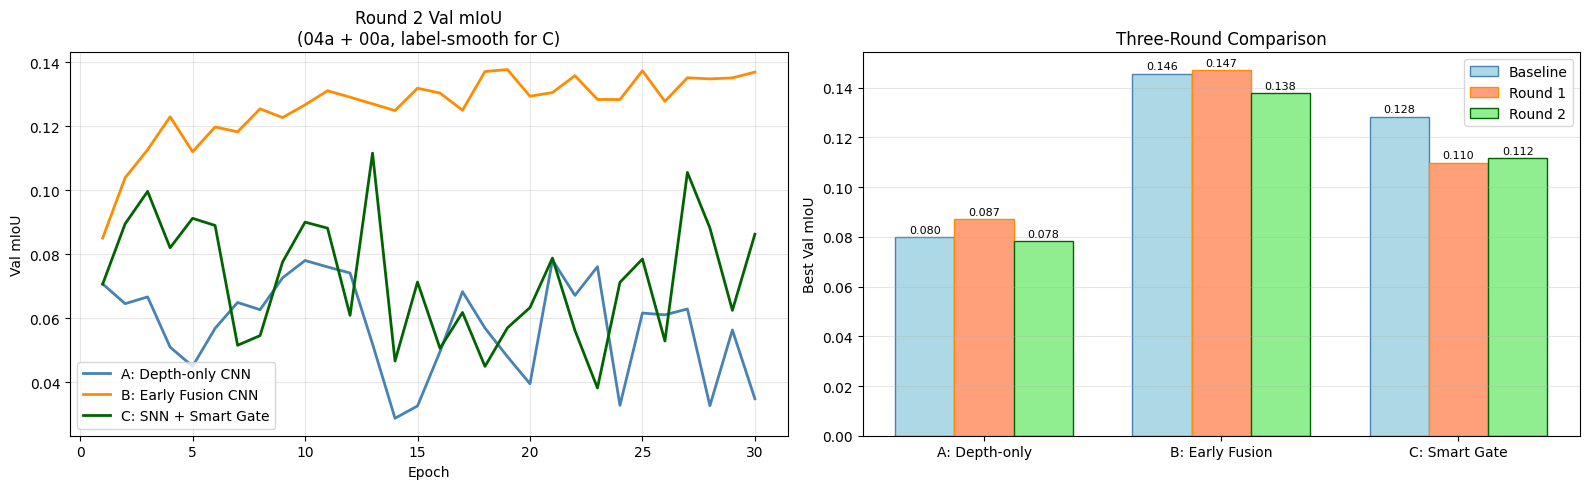

Saved to docs/figures/three_round_comparison.png


In [19]:
# Figure: Val mIoU curves + three-round bar chart
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(epochs_range, history_a['val_miou'], label='A: Depth-only CNN',  color='steelblue',  lw=2)
ax.plot(epochs_range, history_b['val_miou'], label='B: Early Fusion CNN', color='darkorange', lw=2)
ax.plot(epochs_range, history_c['val_miou'], label='C: SNN + Smart Gate', color='darkgreen',  lw=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val mIoU')
ax.set_title('Round 2 Val mIoU\n(04a + 00a, label-smooth for C)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
names = ['A: Depth-only', 'B: Early Fusion', 'C: Smart Gate']
x = np.arange(3); w = 0.25
b1 = ax.bar(x - w, [BASELINE[k] for k in 'ABC'], w, label='Baseline', color='lightblue',   edgecolor='steelblue')
b2 = ax.bar(x,     [R1[k]       for k in 'ABC'], w, label='Round 1',  color='lightsalmon', edgecolor='darkorange')
b3 = ax.bar(x + w, [R2[k]       for k in 'ABC'], w, label='Round 2',  color='lightgreen',  edgecolor='darkgreen')
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('Best Val mIoU')
ax.set_title('Three-Round Comparison')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

fig.tight_layout()
fig.savefig(figures_dir / 'three_round_comparison.png', dpi=150)
plt.show()
print('Saved to docs/figures/three_round_comparison.png')

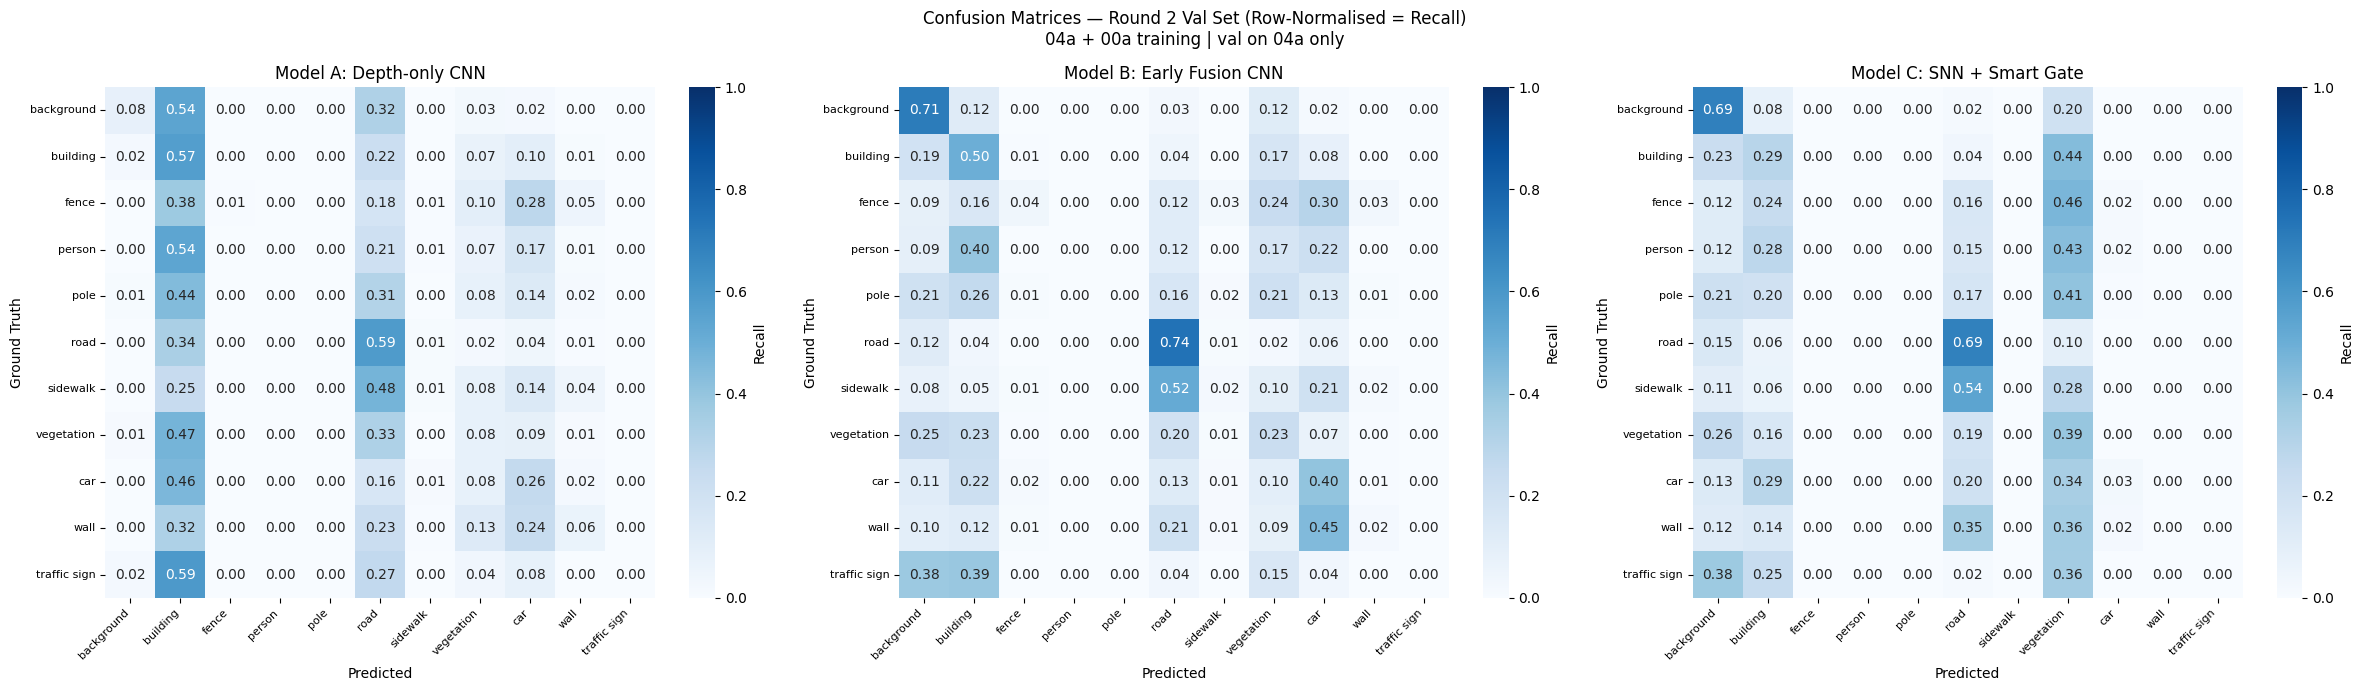

Saved to docs/figures/confusion_matrices_r2.png


In [20]:
# Confusion matrix: best model of each round on val set
def compute_confusion_matrix(model, loader, device, model_id, num_classes=11):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    model.eval()
    with torch.no_grad():
        for ts_b, depth_b, label_b in loader:
            ts_b, depth_b, label_b = (
                ts_b.to(device), depth_b.to(device), label_b.to(device)
            )
            if   model_id == 'A': out = model(depth_b)
            elif model_id == 'B': out = model(ts_b, depth_b)
            else:                 out = model(ts_b, depth_b, num_steps=4)
            preds = out.argmax(dim=1).cpu().numpy().ravel()
            truth = label_b.cpu().numpy().ravel()
            for t, p in zip(truth, preds):
                if 0 <= t < num_classes and 0 <= p < num_classes:
                    cm[t, p] += 1
    return cm


cm_a = compute_confusion_matrix(model_a, val_loader, device, 'A')
cm_b = compute_confusion_matrix(model_b, val_loader, device, 'B')
cm_c = compute_confusion_matrix(model_c, val_loader, device, 'C')

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for ax, cm, title in zip(axes, [cm_a, cm_b, cm_c],
                          ['Model A: Depth-only CNN',
                           'Model B: Early Fusion CNN',
                           'Model C: SNN + Smart Gate']):
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm  = np.where(row_sums > 0, cm / row_sums, 0.0)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=DSEC_CLASS_NAMES,
                yticklabels=DSEC_CLASS_NAMES,
                vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'Recall'})
    ax.set_xlabel('Predicted'); ax.set_ylabel('Ground Truth'); ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

fig.suptitle('Confusion Matrices — Round 2 Val Set (Row-Normalised = Recall)\n'
             '04a + 00a training | val on 04a only', fontsize=12)
fig.tight_layout()
fig.savefig(figures_dir / 'confusion_matrices_r2.png', dpi=150)
plt.show()
print('Saved to docs/figures/confusion_matrices_r2.png')

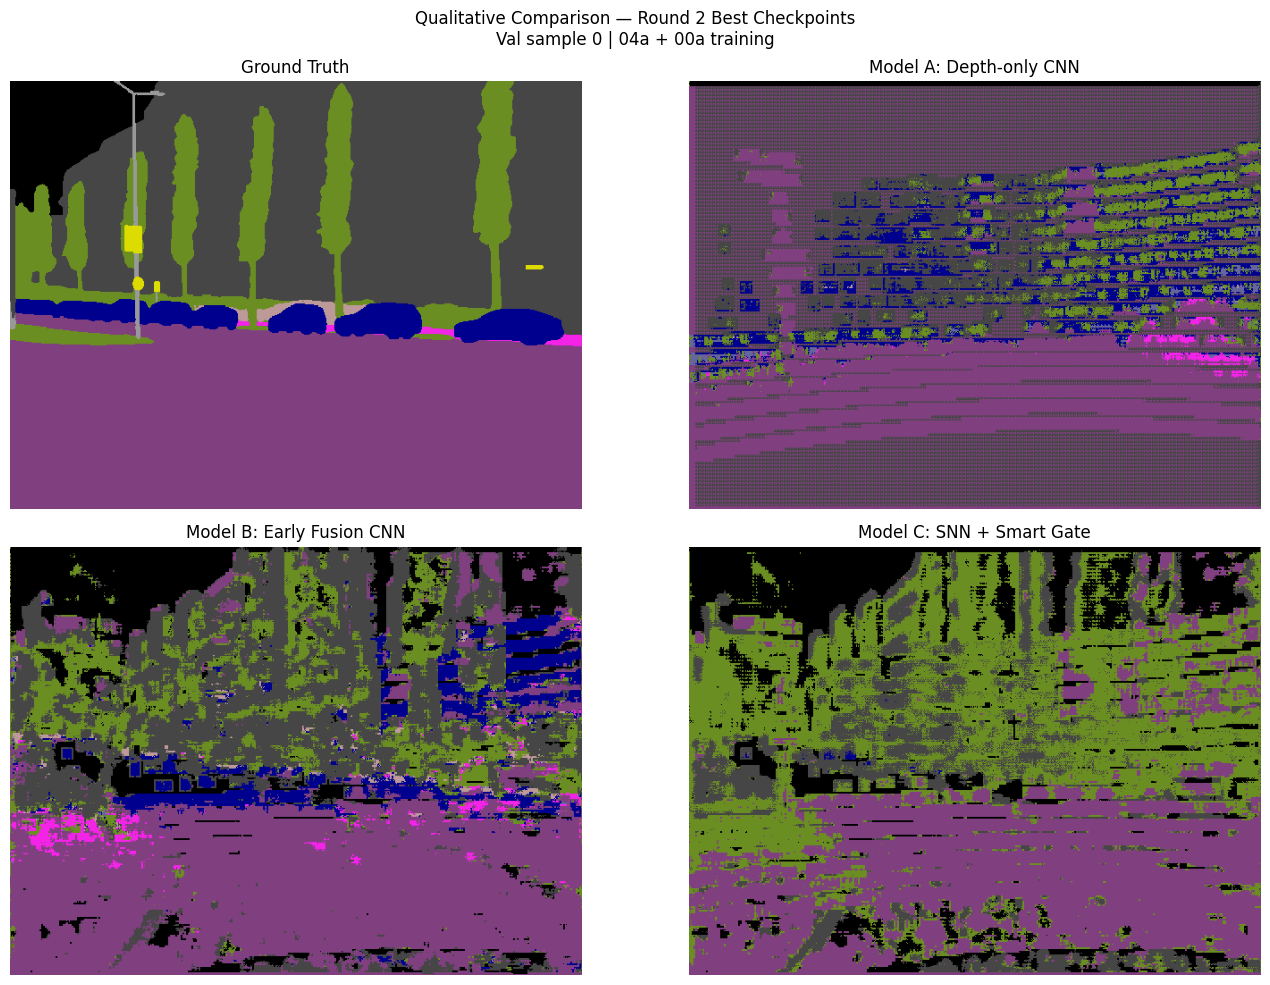

Saved to docs/figures/qualitative_comparison_r2.png


In [21]:
# Qualitative comparison
PALETTE = np.array([
    [0,   0,   0  ], [70,  70,  70 ], [190, 153, 153],
    [220, 20,  60 ], [153, 153, 153], [128, 64,  128],
    [244, 35,  232], [107, 142, 35 ], [0,   0,   142],
    [102, 102, 156], [220, 220, 0  ],
], dtype=np.uint8)

def label_to_rgb(label_np):
    rgb = np.zeros((*label_np.shape, 3), dtype=np.uint8)
    for c in range(len(PALETTE)):
        rgb[label_np == c] = PALETTE[c]
    return rgb

ts_s, depth_s, label_s = val_04[0]
ts_in    = ts_s.unsqueeze(0).to(device)
depth_in = depth_s.unsqueeze(0).to(device)

preds = {}
for model, mid in [(model_a,'A'), (model_b,'B'), (model_c,'C')]:
    model.eval()
    with torch.no_grad():
        if   mid == 'A': out = model(depth_in)
        elif mid == 'B': out = model(ts_in, depth_in)
        else:            out = model(ts_in, depth_in, num_steps=4)
    preds[mid] = out.argmax(dim=1).squeeze(0).cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].imshow(label_to_rgb(label_s.numpy())); axes[0,0].set_title('Ground Truth')
axes[0,1].imshow(label_to_rgb(preds['A']));      axes[0,1].set_title('Model A: Depth-only CNN')
axes[1,0].imshow(label_to_rgb(preds['B']));      axes[1,0].set_title('Model B: Early Fusion CNN')
axes[1,1].imshow(label_to_rgb(preds['C']));      axes[1,1].set_title('Model C: SNN + Smart Gate')
for ax in axes.ravel(): ax.axis('off')
fig.suptitle('Qualitative Comparison — Round 2 Best Checkpoints\n'
             'Val sample 0 | 04a + 00a training', fontsize=12)
fig.tight_layout()
fig.savefig(figures_dir / 'qualitative_comparison_r2.png', dpi=150)
plt.show()
print('Saved to docs/figures/qualitative_comparison_r2.png')

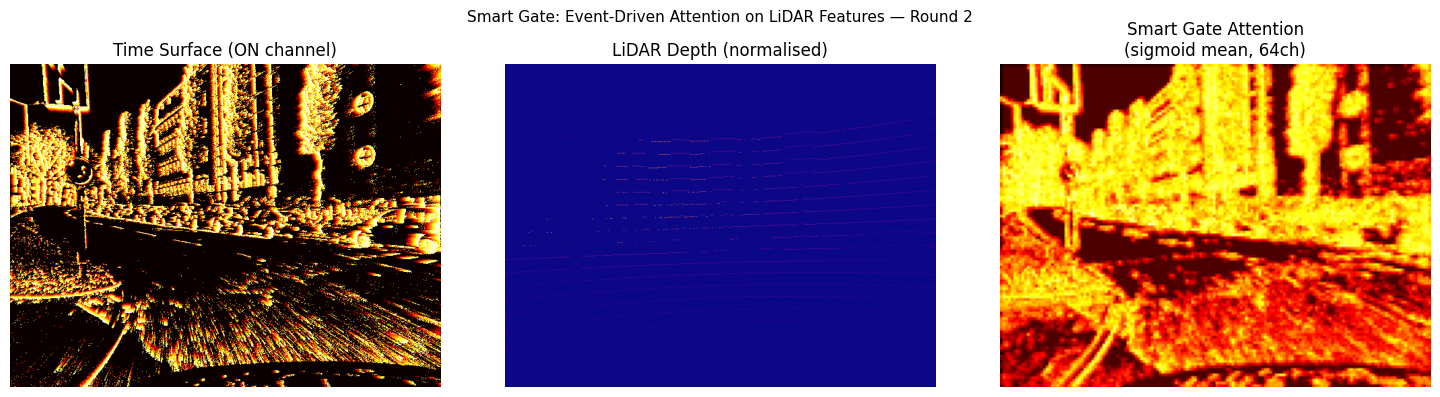

Saved to docs/figures/smart_gate_attention_r2.png


In [22]:
# Smart Gate attention visualisation
with torch.no_grad():
    attn_raw = model_c.snn_branch(ts_in)
    attn_map = torch.sigmoid(attn_raw).mean(dim=1).squeeze().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(ts_s[0].numpy(), cmap='hot');        axes[0].set_title('Time Surface (ON channel)')
axes[1].imshow(depth_s.squeeze().numpy(), cmap='plasma'); axes[1].set_title('LiDAR Depth (normalised)')
axes[2].imshow(attn_map, cmap='hot');               axes[2].set_title('Smart Gate Attention\n(sigmoid mean, 64ch)')
for ax in axes: ax.axis('off')
fig.suptitle('Smart Gate: Event-Driven Attention on LiDAR Features — Round 2', fontsize=11)
fig.tight_layout()
fig.savefig(figures_dir / 'smart_gate_attention_r2.png', dpi=150)
plt.show()
print('Saved to docs/figures/smart_gate_attention_r2.png')
# Note: depth still appears sparse (scan lines visible) — this is genuine LiDAR sparsity,
# not the scale mismatch from the baseline. normalize_depth=True is applied.

---
## Round 2 Post trainning Analyisis and Round 3 Strategy

### What Round 2 showed

| Model | R1 | R2 | Δ |
|-------|-----|-----|---|
| A: Depth-only CNN | 0.0871 | 0.0831 | −0.004 |
| B: Early Fusion CNN | 0.1470 | 0.1385 | −0.009 |
| C: SNN + Smart Gate | 0.1098 | 0.1035 | −0.006 |

All three models got **worse** in R2 despite 2.7× more training data. The per-class IoU table reveals where the regressions happened.

### Per-class diagnosis

**Person and pole: still 0.000 across all models, all rounds.**
Even with 749 training samples and genuine person pixels present (0.121% combined), no model learned to detect them. This is the definitive evidence that upweighting sub-percent classes at this dataset scale is innefective as the gradient signal from almost 550 person pixels per frame is too sparse for a 3-layer encoder to distinguish from background noise. R3 fix: neutral weight.

**Model C car IoU: 0.0976 (R1) → 0.0048 (R2) amlost collapse.**
The confusion matrix shows 48% of actual car pixels being predicted as *building* by Model C. Root cause: `zurich_city_00_a` has 2.5% car pixels vs 4.7% in 04a. Training on the combined set diluted the car signal, and label smoothing softened the predictions further. High car recall (0.48 in confusion matrix) but very bad precision it predicts car across large building regions.

**Sidewalk regressed everywhere** (A: 0.022→0.020, B: 0.040→0.012, C: 0.006→0.000).
Sidewalk visually differs between a highway sequence (04a, narrow shoulder) and a city street (00a, wide pavement). Training on the mix confused the model's spatial prior for what sidewalk looks like, which is then tested on 04a only.

**Vegetation: Model A consistently beats B and C across all three rounds.**
R1: A=0.254, B=0.232, C=0.128. R2: A=0.257, B=0.198, C=0.099.
Depth-only CNN is better at vegetation than either fusion model. Trees have a distinctive LiDAR return profile (dense canopy at 5–15m range); the event camera adds noise for this class rather than signal.

**Smart Gate attention figure : depth map still dark blue.**
Important distinction from the baseline: in the baseline notebook the near-solid-blue depth map was caused by scale mismatch (raw 0–104m values). Here, `normalize_depth=True` is applied, so values are in [0,1]. The darkness in val sample 0 is caused by genuinely sparse LiDAR returns; the scan lines are visible as thin horizontal streaks (the 16 VLP-16 rings projected onto the image plane). Model A's horizontal stripe artifacts in the qualitative comparison come from the same scan line sparsity.

### Possible Root causes of R2 overall regression

1. **The Domain shift**  training distribution (04a highway + 00a city street) does not match validation distribution (04a only). Class appearance (sidewalk, car density) differs between sequences; the model optimises for the average and loses 04a specificity.

2. **Some upweighting unlearnable classes**  person and pole received non-neutral weights despite producing zero IoU across all rounds. The wasted upweighting budget adds gradient noise with no measurable benefit.

### What changes for Round 3

Two targeted fixes: dataset, architecture, and val set unchanged.

**Fix 1 - Frequency-threshold weights.**
Only apply sqrt inverse-frequency upweighting to classes with ≥1% pixel frequency. Classes below the threshold get neutral weight = 1.0:
```
neutral  (< 1%): fence 0.99%, person 0.12%, wall 0.56%, traffic sign 0.64%
upweighted (≥1%): background, building, pole, road, sidewalk, vegetation, car
```
Removing the person upweighting stops noise from entering every training step. Keeping car upweighted (3.4%) directly addresses the R2 car collapse.

**Fix 2  AdamW + ReduceLROnPlateau.**
`AdamW(weight_decay=1e-4)` adds L2 regularisation, improving generalisation to the 04a val distribution.
`ReduceLROnPlateau(patience=5, factor=0.5)` halves the learning rate when val mIoU plateaus for 5 epochs rather than running fixed-rate to epoch 30.

### Notes for continue work from here

- Models re-initialised from scratch - not loading R2 checkpoints
- Checkpoints saved as `model_*_r3_best.pt` - R2 results preserved in `model_*_r2_best.pt`
- Val set unchanged: 04a only, 70 samples, seed=42
- Training set unchanged: 04a train (280) + all 00a (469) = 749 samples
- Model C keeps `label_smoothing=0.1` - weighted CE remains incompatible with SNN gradient unrolling across 4 time steps (documented finding from R1)
- `EPOCHS_R3 = 40` - extra headroom for the scheduler to find a better basin

In [23]:
# Round 3 weights: threshold-based, only upweight learnable classes
# Classes with < 1% pixel frequency in the combined dataset are set to
# neutral weight (1.0). They appear too rarely to produce reliable gradient
# signal — upweighting them in R2 added noise and hurt all three models.

FREQ_THRESHOLD = 0.01  # 1% of pixels

freq_combined = counts_combined / counts_combined.sum()
learnable     = freq_combined >= FREQ_THRESHOLD  # boolean mask, shape (11,)

weights_r3 = np.ones(NUM_CLASSES, dtype=np.float64)  # default neutral
weights_r3[learnable] = 1.0 / (np.sqrt(freq_combined[learnable]) + 1e-6)
weights_r3 /= weights_r3.mean()
weights_r3  = np.clip(weights_r3, None, 2.0)
weights_r3 /= weights_r3.mean()

class_weights_r3 = torch.tensor(weights_r3, dtype=torch.float32)

print(f'Round 3 class weights  (threshold = {FREQ_THRESHOLD*100:.0f}%)')
print(f'{"Class":<15} {"Freq%":>7} {"Weight":>8}  Status')
print('-' * 55)
for name, freq, w, learn in zip(DSEC_CLASS_NAMES, freq_combined,
                                 class_weights_r3, learnable):
    status = 'upweighted' if learn else 'neutral  <- below 1% threshold'
    print(f'{name:<15} {freq*100:>6.3f}% {w.item():>8.3f}  {status}')

print(f'\nPerson weight  R2={2.292:.3f}  R3={class_weights_r3[3].item():.3f}')
print(f'Road weight    R2={0.221:.3f}  R3={class_weights_r3[5].item():.3f}')
print(f'Car weight     R2={0.729:.3f}  R3={class_weights_r3[8].item():.3f}  <- car is learnable')

Round 3 class weights  (threshold = 1%)
Class             Freq%   Weight  Status
-------------------------------------------------------
background      11.608%    1.098  upweighted
building        22.056%    0.797  upweighted
fence            0.993%    0.374  neutral  <- below 1% threshold
person           0.121%    0.374  neutral  <- below 1% threshold
pole             1.246%    2.208  upweighted
road            37.385%    0.612  upweighted
sidewalk         3.919%    1.890  upweighted
vegetation      18.034%    0.881  upweighted
car              3.440%    2.017  upweighted
wall             0.558%    0.374  neutral  <- below 1% threshold
traffic sign     0.640%    0.374  neutral  <- below 1% threshold

Person weight  R2=2.292  R3=0.374
Road weight    R2=0.221  R3=0.612
Car weight     R2=0.729  R3=2.017  <- car is learnable


In [24]:
#  Round 3 model setup — fresh weights, AdamW, scheduler
EPOCHS_R3 = 60   # extra headroom; scheduler reduces LR when plateau hit
LR_R3     = 1e-3

model_a_r3 = DepthOnlyCNN(num_classes=NUM_CLASSES).to(device)
model_b_r3 = EarlyFusionCNN(num_classes=NUM_CLASSES).to(device)
model_c_r3 = SmartGateModel(num_classes=NUM_CLASSES, beta=0.9).to(device)

criterion_ab_r3 = nn.CrossEntropyLoss(weight=class_weights_r3.to(device))
criterion_c_r3 = nn.CrossEntropyLoss(weight=class_weights_r3.to(device), label_smoothing=0.1)

print('Round 3 setup')
print(f'  Optimizer : AdamW(lr={LR_R3}, weight_decay=1e-4)')
print(f'  Scheduler : ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-5)')
print(f'  Epochs    : {EPOCHS_R3}')
print(f'  Weights   : threshold-based (>=1% classes only, neutral below)')
print(f'  Crit C    : label_smoothing=0.1  (weighted CE still incompatible with SNN)')
print(f'  Grad clip : max_norm=1.0')

Round 3 setup
  Optimizer : AdamW(lr=0.001, weight_decay=1e-4)
  Scheduler : ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-5)
  Epochs    : 60
  Weights   : threshold-based (>=1% classes only, neutral below)
  Crit C    : label_smoothing=0.1  (weighted CE still incompatible with SNN)
  Grad clip : max_norm=1.0


In [25]:
#  Round 3 training: AdamW + ReduceLROnPlateau
def train_r3(model, model_id, criterion, label):
    print(f"\n{'='*65}")
    print(f'Training {label} — Round 3')
    print(f"{'='*65}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR_R3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=5, factor=0.5, min_lr=1e-5, verbose=False
    )
    history = {
        'train_loss': [], 'val_loss': [], 'val_miou': [], 'lr': [],
        'best_per_class': None, 'label': label
    }
    best_miou = 0.0

    for epoch in range(EPOCHS_R3):
        model.train()
        total_loss = 0.0
        for ts_b, depth_b, label_b in train_loader:
            ts_b, depth_b, label_b = (
                ts_b.to(device), depth_b.to(device), label_b.to(device)
            )
            optimizer.zero_grad()
            if   model_id == 'A': logits = model(depth_b)
            elif model_id == 'B': logits = model(ts_b, depth_b)
            else:                 logits = model(ts_b, depth_b, num_steps=4)
            loss = criterion(logits, label_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()

        val_loss, val_miou, per_class = evaluate_full(
            model, val_loader, criterion, device, model_id, NUM_CLASSES
        )
        avg_train  = total_loss / len(train_loader)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(avg_train)
        history['val_loss'].append(val_loss)
        history['val_miou'].append(val_miou)
        history['lr'].append(current_lr)

        scheduler.step(val_miou)
        new_lr = optimizer.param_groups[0]['lr']

        if val_miou > best_miou:
            best_miou = val_miou
            history['best_per_class'] = per_class
            torch.save(model.state_dict(), ckpt_dir / f'model_{model_id}_r3_best.pt')

        if (epoch + 1) % 5 == 0 or epoch == 0:
            lr_note = f'  <- LR reduced to {new_lr:.1e}' if new_lr < current_lr else ''
            print(f'  Epoch {epoch+1:3d}/{EPOCHS_R3} | '
                  f'train={avg_train:.4f} | val_loss={val_loss:.4f} | '
                  f'val_mIoU={val_miou:.4f} | lr={current_lr:.1e}{lr_note}')

    print(f'  Best val mIoU: {best_miou:.4f}')
    return history, best_miou


history_a_r3, best_a_r3 = train_r3(model_a_r3, 'A', criterion_ab_r3, 'Model A: Depth-only CNN')
history_b_r3, best_b_r3 = train_r3(model_b_r3, 'B', criterion_ab_r3, 'Model B: Early Fusion CNN')
history_c_r3, best_c_r3 = train_r3(model_c_r3, 'C', criterion_c_r3,  'Model C: SNN + Smart Gate')

R3 = {'A': best_a_r3, 'B': best_b_r3, 'C': best_c_r3}

print(f"\n{'='*65}")
print('ROUND 3 TRAINING COMPLETE')
print(f"  A: {best_a_r3:.4f}  B: {best_b_r3:.4f}  C: {best_c_r3:.4f}")
print(f"  C beats B: {best_c_r3 > best_b_r3}")
print(f"{'='*65}")


Training Model A: Depth-only CNN — Round 3


C:\Users\mtvol\source\repos\cnn-snn-lidar-fusion-comparison\capstonevenv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch   1/60 | train=1.7302 | val_loss=3.4724 | val_mIoU=0.0499 | lr=1.0e-03
  Epoch   5/60 | train=1.6207 | val_loss=4.0192 | val_mIoU=0.0502 | lr=1.0e-03
  Epoch  10/60 | train=1.6077 | val_loss=1.7683 | val_mIoU=0.0549 | lr=1.0e-03
  Epoch  15/60 | train=1.5989 | val_loss=1.5866 | val_mIoU=0.0702 | lr=5.0e-04
  Epoch  20/60 | train=1.5975 | val_loss=3.1702 | val_mIoU=0.0627 | lr=5.0e-04
  Epoch  25/60 | train=1.5974 | val_loss=1.7076 | val_mIoU=0.0731 | lr=5.0e-04
  Epoch  30/60 | train=1.5951 | val_loss=2.1262 | val_mIoU=0.0652 | lr=5.0e-04
  Epoch  35/60 | train=1.5910 | val_loss=1.6111 | val_mIoU=0.0761 | lr=2.5e-04
  Epoch  40/60 | train=1.5894 | val_loss=1.7326 | val_mIoU=0.0778 | lr=2.5e-04
  Epoch  45/60 | train=1.5906 | val_loss=1.6170 | val_mIoU=0.0791 | lr=2.5e-04  <- LR reduced to 1.3e-04
  Epoch  50/60 | train=1.5880 | val_loss=1.5617 | val_mIoU=0.0840 | lr=1.3e-04
  Epoch  55/60 | train=1.5863 | val_loss=1.5455 | val_mIoU=0.0801 | lr=1.3e-04
  Epoch  60/60 | train=1.5

*Generative AI was used to assist in the creation of some sections of this notebook*